<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Fall_2026/blob/main/Module%202/8_Matminer_perovskites_SISSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!pip install -qq matminer

In [21]:
from matminer.datasets import load_dataset

df = load_dataset("castelli_perovskites")

In [22]:
df

,fermi level,fermi width,e_form,gap is direct,structure,mu_b,formula,vbm,cbm,gap gllbsc
0,0.312138,0.001837,2.16,True,"[[0. 0. 0.] Rh, [1.97726555 1.97726555 1.97726...",1.974478e-02,RhTeN3,6.187694,6.187694,0.0
1,0.297083,0.001837,1.52,True,"[[2.54041798 0. 0. ] Hf, [1.020...",-2.253054e-05,HfTeO3,6.033125,6.033125,0.0
2,0.191139,0.003675,1.48,True,"[[0.60790913 0. 0. ] Re, [2.186...",4.982109e+00,ReAsO2F,6.602253,6.602253,0.0
3,0.316346,0.001837,1.24,True,"[[2.83091357 0. 0. ] W, [2.6573...",-8.684496e-01,WReO2S,5.738462,5.738462,0.0
4,0.312658,0.003675,0.62,True,"[[0.00518937 0. 0. ] Bi, [2.172...",2.164069e-15,BiHfO2F,6.074736,6.074736,0.0
...,...,...,...,...,...,...,...,...,...,...
18923,0.123028,0.001837,1.66,True,"[[4.44077598 0. 0. ] Rb, [2.652...",1.566419e+00,RbPdO2S,5.164060,5.164060,0.0
18924,0.081229,0.001837,2.12,True,[[4.56913824e-03 7.21569024e-19 0.00000000e+00...,1.993566e+00,LiBaO2N,5.062501,5.062501,0.0
18925,0.189810,0.003675,1.50,True,"[[0.0040044 0. 0. ] Zn, [1.821570...",1.599586e+00,ZnBeOFN,6.589724,6.589724,0.0
18926,0.209947,0.001837,2.48,True,"[[0. 0. 0.] Ca, [2.16744896 2.16744896 2.16744...",3.280734e+00,CaTlN3,5.411525,5.411525,0.0


In [23]:
df.describe()

,fermi level,fermi width,e_form,mu_b,vbm,cbm,gap gllbsc
count,18928.000000,18928.000000,18928.000000,18928.000000,18928.000000,18928.000000,18928.000000
mean,0.213770,0.002362,1.470932,0.870669,5.853705,5.782879,0.070813
std,0.082382,0.000830,0.742502,1.695944,0.509437,0.530577,0.459684
min,-0.096153,0.001837,-0.640000,-5.763449,4.264696,1.474852,0.000000
25%,0.163024,0.001837,0.960000,0.000000,5.519486,5.475086,0.000000
50%,0.216352,0.001837,1.360000,0.140870,5.853191,5.819146,0.000000
75%,0.267705,0.003675,1.840000,1.866425,6.172323,6.128552,0.000000
max,0.524917,0.003675,5.160000,9.659854,9.410918,7.222349,7.000000


In [24]:
from matminer.featurizers.conversions import StrToComposition
df = StrToComposition().featurize_dataframe(df, "formula")
df.head()

StrToComposition:   0%|          | 0/18928 [00:00<?, ?it/s]

,fermi level,fermi width,e_form,gap is direct,structure,mu_b,formula,vbm,cbm,gap gllbsc,composition
0,0.312138,0.001837,2.16,True,"[[0. 0. 0.] Rh, [1.97726555 1.97726555 1.97726...",1.974478e-02,RhTeN3,6.187694,6.187694,0.0,"(Rh, Te, N)"
1,0.297083,0.001837,1.52,True,"[[2.54041798 0. 0. ] Hf, [1.020...",-2.253054e-05,HfTeO3,6.033125,6.033125,0.0,"(Hf, Te, O)"
2,0.191139,0.003675,1.48,True,"[[0.60790913 0. 0. ] Re, [2.186...",4.982109e+00,ReAsO2F,6.602253,6.602253,0.0,"(Re, As, O, F)"
3,0.316346,0.001837,1.24,True,"[[2.83091357 0. 0. ] W, [2.6573...",-8.684496e-01,WReO2S,5.738462,5.738462,0.0,"(W, Re, O, S)"
4,0.312658,0.003675,0.62,True,"[[0.00518937 0. 0. ] Bi, [2.172...",2.164069e-15,BiHfO2F,6.074736,6.074736,0.0,"(Bi, Hf, O, F)"


In [25]:
from matminer.featurizers.composition import ElementProperty

ep_feat = ElementProperty.from_preset(preset_name="magpie")
df = ep_feat.featurize_dataframe(df, col_id="composition")  # input the "composition" column to the featurizer
df.head()

ElementProperty:   0%|          | 0/18928 [00:00<?, ?it/s]

,fermi level,fermi width,e_form,gap is direct,structure,mu_b,formula,vbm,cbm,gap gllbsc,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,0.312138,0.001837,2.16,True,"[[0. 0. 0.] Rh, [1.97726555 1.97726555 1.97726...",1.974478e-02,RhTeN3,6.187694,6.187694,0.0,...,0.0,0.0,0.0,0.0,152.0,225.0,73.0,191.8,15.92,194.0
1,0.297083,0.001837,1.52,True,"[[2.54041798 0. 0. ] Hf, [1.020...",-2.253054e-05,HfTeO3,6.033125,6.033125,0.0,...,0.0,0.0,0.0,0.0,12.0,194.0,182.0,76.4,77.28,12.0
2,0.191139,0.003675,1.48,True,"[[0.60790913 0. 0. ] Re, [2.186...",4.982109e+00,ReAsO2F,6.602253,6.602253,0.0,...,0.0,0.0,0.0,0.0,12.0,194.0,182.0,79.8,80.16,12.0
3,0.316346,0.001837,1.24,True,"[[2.83091357 0. 0. ] W, [2.6573...",-8.684496e-01,WReO2S,5.738462,5.738462,0.0,...,0.0,0.0,0.0,0.0,12.0,229.0,217.0,103.4,86.48,12.0
4,0.312658,0.003675,0.62,True,"[[0.00518937 0. 0. ] Bi, [2.172...",2.164069e-15,BiHfO2F,6.074736,6.074736,0.0,...,0.0,0.0,0.0,0.0,12.0,194.0,182.0,49.0,58.00,12.0


In [26]:
df.columns

Index(['fermi level', 'fermi width', 'e_form', 'gap is direct', 'structure',
       'mu_b', 'formula', 'vbm', 'cbm', 'gap gllbsc',
       ...
       'MagpieData range GSmagmom', 'MagpieData mean GSmagmom',
       'MagpieData avg_dev GSmagmom', 'MagpieData mode GSmagmom',
       'MagpieData minimum SpaceGroupNumber',
       'MagpieData maximum SpaceGroupNumber',
       'MagpieData range SpaceGroupNumber', 'MagpieData mean SpaceGroupNumber',
       'MagpieData avg_dev SpaceGroupNumber',
       'MagpieData mode SpaceGroupNumber'],
      dtype='object', length=143)

In [27]:
y = df['gap is direct'].values

excluded = ['fermi level', 'fermi width', 'e_form', 'gap is direct', 'structure',
       'mu_b', 'formula', 'vbm', 'cbm', 'gap gllbsc', 'composition']
X = df.drop(excluded, axis=1)

print("There are {} possible descriptors:\n\n{}".format(X.shape[1], X.columns.values))

There are 132 possible descriptors:

['MagpieData minimum Number' 'MagpieData maximum Number'
 'MagpieData range Number' 'MagpieData mean Number'
 'MagpieData avg_dev Number' 'MagpieData mode Number'
 'MagpieData minimum MendeleevNumber' 'MagpieData maximum MendeleevNumber'
 'MagpieData range MendeleevNumber' 'MagpieData mean MendeleevNumber'
 'MagpieData avg_dev MendeleevNumber' 'MagpieData mode MendeleevNumber'
 'MagpieData minimum AtomicWeight' 'MagpieData maximum AtomicWeight'
 'MagpieData range AtomicWeight' 'MagpieData mean AtomicWeight'
 'MagpieData avg_dev AtomicWeight' 'MagpieData mode AtomicWeight'
 'MagpieData minimum MeltingT' 'MagpieData maximum MeltingT'
 'MagpieData range MeltingT' 'MagpieData mean MeltingT'
 'MagpieData avg_dev MeltingT' 'MagpieData mode MeltingT'
 'MagpieData minimum Column' 'MagpieData maximum Column'
 'MagpieData range Column' 'MagpieData mean Column'
 'MagpieData avg_dev Column' 'MagpieData mode Column'
 'MagpieData minimum Row' 'MagpieData maximum 

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the logistic regression model
model = LogisticRegression(max_iter=100)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

Accuracy: 0.9672477548864237
Classification Report:
              precision    recall  f1-score   support

       False       0.00      0.00      0.00       124
        True       0.97      1.00      0.98      3662

    accuracy                           0.97      3786
   macro avg       0.48      0.50      0.49      3786
weighted avg       0.94      0.97      0.95      3786



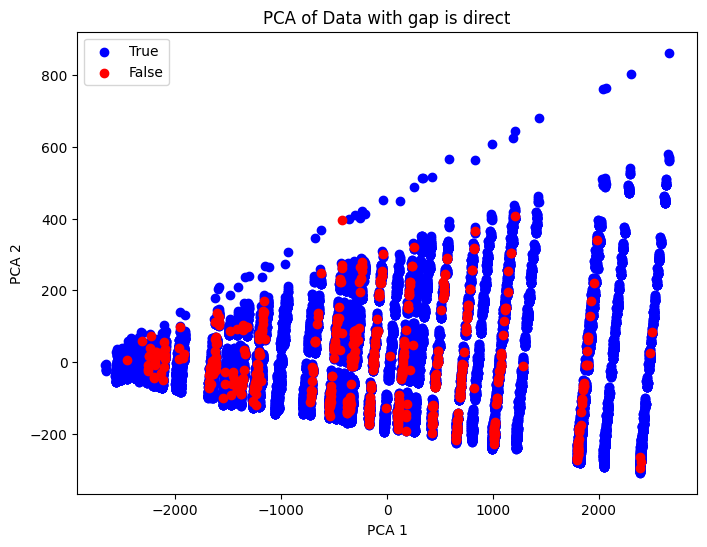

In [29]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y, 0], X_pca[y, 1], c='blue', label='True')
plt.scatter(X_pca[~y, 0], X_pca[~y, 1], c='red', label='False')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA of Data with gap is direct')
plt.legend()
plt.show()

In [30]:
import xgboost as xgb
import pandas as pd

# Initialize and train the XGBoost classifier
model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)
model.fit(X_train, y_train)

# Get feature importances
feature_importances = model.feature_importances_

# Create a pandas Series for easier handling
feature_importances = pd.Series(feature_importances, index=X.columns)

# Sort feature importances and get the top 10
top_10_features = feature_importances.sort_values(ascending=False).head(10)

print("Top 10 most significant features:")
print(top_10_features)

Top 10 most significant features:
MagpieData maximum NUnfilled    0.166155
MagpieData mean NpUnfilled      0.125362
MagpieData mean NUnfilled       0.065918
MagpieData mean Column          0.063718
MagpieData avg_dev GSbandgap    0.040166
MagpieData minimum Column       0.036695
MagpieData mean NValence        0.031305
MagpieData maximum NdValence    0.025646
MagpieData mean NpValence       0.023333
MagpieData maximum NValence     0.017690
dtype: float32


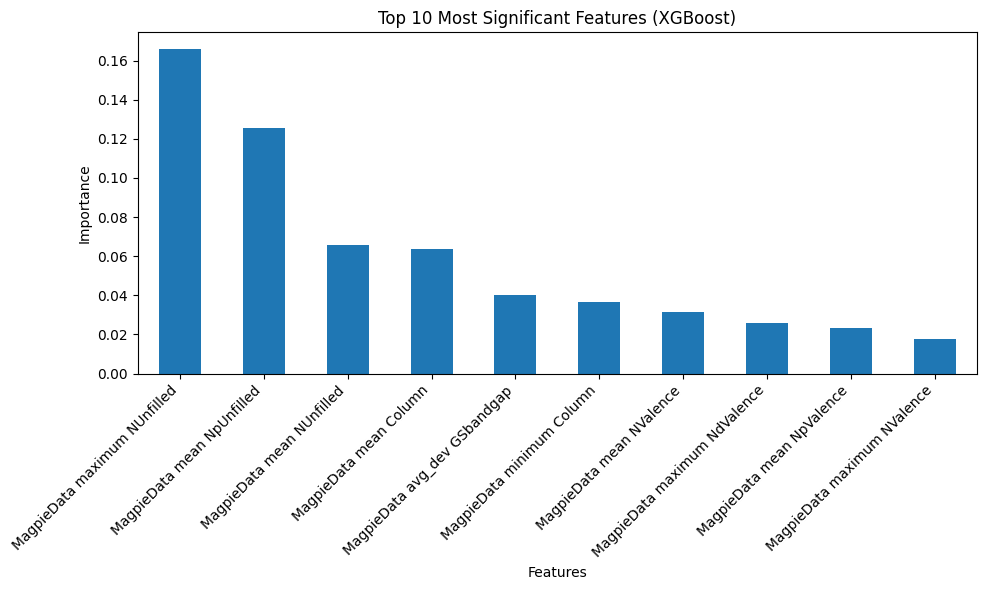

In [31]:
import matplotlib.pyplot as plt

# Plot the top 10 feature importances as a bar graph
plt.figure(figsize=(10, 6))
top_10_features.plot(kind='bar')
plt.title('Top 10 Most Significant Features (XGBoost)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

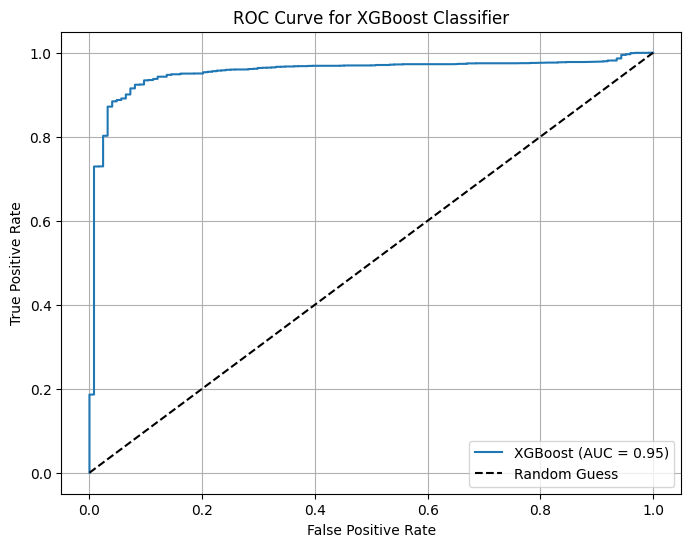

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost Classifier')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
!pip -qq install TorchSisso scikit-learn matplotlib pandas sympy

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from TorchSisso import SissoModel
import sympy as sp

In [34]:
y1 = df['gap is direct'].values

included = ['MagpieData maximum NUnfilled', 'MagpieData mean NpUnfilled', 'MagpieData mean Column',
            'MagpieData mean NUnfilled', 'MagpieData minimum Column', 'MagpieData avg_dev GSbandgap']
X1 = df[included]

print("There are {} possible descriptors:\n\n{}".format(X1.shape[1], X1.columns.values))

There are 6 possible descriptors:

['MagpieData maximum NUnfilled' 'MagpieData mean NpUnfilled'
 'MagpieData mean Column' 'MagpieData mean NUnfilled'
 'MagpieData minimum Column' 'MagpieData avg_dev GSbandgap']


In [35]:
y1

array([ True,  True,  True, ...,  True,  True,  True])

In [36]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             roc_auc_score, f1_score, precision_score,
                             recall_score, confusion_matrix)
from TorchSisso import SissoModel
import sympy as sp

# --- INPUTS ---
# df: your DataFrame with the 6 columns below
cols = [
    'MagpieData maximum NUnfilled',
    'MagpieData mean NpUnfilled',
    'MagpieData mean Column',
    'MagpieData mean NUnfilled',
    'MagpieData minimum Column',
    'MagpieData avg_dev GSbandgap'
]
X = df[cols].copy()
y = np.asarray(y1, dtype=float)   # True/False -> 1.0/0.0

# --- CLEANUP ---
# keep only rows with no NaNs and valid y
mask = (~X.isna().any(axis=1)).values & ~np.isnan(y)
X = X.loc[mask].reset_index(drop=True)
y = y[mask]

# TorchSISSO is happier with simple column names
safe_cols = [f'x{i+1}' for i in range(X.shape[1])]
name_map = dict(zip(cols, safe_cols))
X_safe = X.rename(columns=name_map)

# --- SPLIT ---
strat = y if np.unique(y).size == 2 else None
Xtr, Xte, ytr, yte = train_test_split(
    X_safe, y, test_size=0.25, stratify=strat, random_state=0
)

# Build training DataFrame (TorchSISSO expects first column = target y)
train_df = pd.concat([pd.Series(ytr, name='y'), Xtr.reset_index(drop=True)], axis=1)
test_df  = pd.concat([pd.Series(yte, name='y'), Xte.reset_index(drop=True)], axis=1)

# --- TORCHSISSO ---
# Use a "safe" operator set (no raw ln to avoid domain issues)
operators = ['+','-','*','/','pow(2)','pow(3)','abs','sqrt']

sm = SissoModel(
    train_df,        # positional arg: df with y first, then features
    operators=operators,
    n_expansion=3,   # try 2–4
    n_term=2,        # 1–3 terms for interpretability
    k=50,            # SIS screening pool
    use_gpu=False
)

out = sm.fit()
try:
    rmse, equation, r2, final_eq = out
except ValueError:
    rmse, equation, r2 = out
    final_eq = None

print("TorchSISSO equation:", equation)
print("Train RMSE:", rmse, " | Train R^2:", r2)

************************************************ Starting Feature Space Construction in cpu ************************************************ 



************************************************ Starting 1 level of feature expansion...************************************************ 

************************************************ 1 Feature Expansion Completed with feature space size::: 88 ************************************************ 

************************************************ Time taken to create the space is::: 0.02945089340209961  Seconds...************************************************ 

************************************************ Starting 2 level of feature expansion...************************************************ 

************************************************ 2 Feature Expansion Completed with feature space size::: 17746 ************************************************ 

************************************************ Time taken to create the space is::

In [37]:
# --- MAKE THE EQUATION CALLABLE ---
sym_map = {s: sp.symbols(s) for s in safe_cols}
eq_str = str(equation).replace('ln(', 'log(').replace('pow(', 'Pow(').replace('^', '**')
expr = sp.sympify(eq_str, locals={
    **sym_map, 'sin': sp.sin, 'cos': sp.cos, 'sqrt': sp.sqrt, 'abs': sp.Abs,
    'exp': sp.exp, 'log': sp.log, 'Pow': sp.Pow
})
f = sp.lambdify(tuple(sym_map.values()), expr, modules={
    'numpy': np, 'sin': np.sin, 'cos': np.cos, 'sqrt': np.sqrt,
    'abs': np.abs, 'exp': np.exp, 'log': np.log, 'Pow': np.power
})

In [38]:
# --- EVALUATE AS CLASSIFIER (threshold 0.5) ---
Xte_vals = [Xte[c].values for c in safe_cols]
yhat = np.asarray(f(*Xte_vals), dtype=float)
ypred = (yhat >= 0.5).astype(int)

print("Test accuracy      :", accuracy_score(yte, ypred))
print("Balanced accuracy  :", balanced_accuracy_score(yte, ypred))
try:
    print("ROC AUC (prob-like):", roc_auc_score(yte, yhat))
except Exception:
    pass
print("F1                 :", f1_score(yte, ypred))
print("Precision          :", precision_score(yte, ypred))
print("Recall             :", recall_score(yte, ypred))
print("Confusion matrix:\n", confusion_matrix(yte, ypred))

# Pretty-print equation using ORIGINAL feature names
pretty = str(expr)
for orig, safe in name_map.items():
    pretty = pretty.replace(safe, f'[{orig}]')
print("\nEquation with original names:\n", pretty)

Test accuracy      : 0.9685122569737954
Balanced accuracy  : 0.5
ROC AUC (prob-like): 0.787547209046564
F1                 : 0.9840042941492216
Precision          : 0.9685122569737954
Recall             : 1.0
Confusion matrix:
 [[   0  149]
 [   0 4583]]

Equation with original names:
 -0.0380270683*[MagpieData maximum NUnfilled]*[MagpieData mean NpUnfilled]/([MagpieData mean NUnfilled] + [MagpieData avg_dev GSbandgap]) + 0.9609375
